<a href="https://colab.research.google.com/github/SebastianUrrego/LabParalela/blob/main/Paralela_lab_paralelismo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/depctg/udacity-cs344-colab.git

Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 17.14 MiB/s, done.
Resolving deltas: 100% (43/43), done.


In [ ]:
%cd /content/udacity-cs344-colab

/content/udacity-cs344-colab


In [ ]:
!ls

notebook  README.md  src


In [ ]:
!pip install numba

In [ ]:
from numba import cuda
print("GPU disponible:", cuda.is_available())

GPU disponible: True


 Esto verifica que si estamos usando la GPU local de colab, esto es impoortante ya que usaremos el entorno de colab, por lo que **NO** correra riesgo nuestras graficas.

# HW1
# 🧪 HW1 - Procesamiento de Imágenes con CUDA

## 📌 Descripción

En este ejercicio se implementa un procesamiento básico de imágenes utilizando paralelismo en GPU mediante CUDA en Python. El objetivo principal es aplicar una transformación a cada píxel de una imagen en escala de grises, aprovechando la ejecución paralela para mejorar el rendimiento.

## 🎯 Objetivo

Aplicar operaciones simples sobre una imagen (como inversión de colores y ajuste de brillo) utilizando programación paralela en GPU, y comparar su rendimiento con una implementación secuencial en CPU.

## ⚙️ Metodología

- Se carga una imagen en escala de grises.
- Se define un kernel CUDA donde cada hilo procesa un píxel de la imagen.
- Se realiza una transformación sobre cada píxel:
  - Inversión de intensidad (255 - valor del píxel)
  - Ajuste de brillo
- Se ejecuta el kernel en la GPU usando paralelismo masivo.
- Se compara el resultado con una versión secuencial en CPU.

In [ ]:
import numpy as np
from numba import cuda
from PIL import Image
import matplotlib.pyplot as plt
import time

In [ ]:
!ls /content/udacity-cs344-colab

notebook  README.md  src


In [ ]:
%cd /content/udacity-cs344-colab/src
!ls

/content/udacity-cs344-colab/src
CMakeLists.txt	Final  HW1  HW2  HW3  HW4  HW5	HW6


In [ ]:
%cd HW1
!ls

[Errno 2] No such file or directory: 'HW1'
/content/udacity-cs344-colab/src/HW1
cinque_terre.gold	compare.h  reference_calc.cpp  utils.h
cinque_terre_small.jpg	HW1.cpp    reference_calc.h
CMakeLists.txt		main.cpp   student_func.cu
compare.cpp		Makefile   timer.h


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

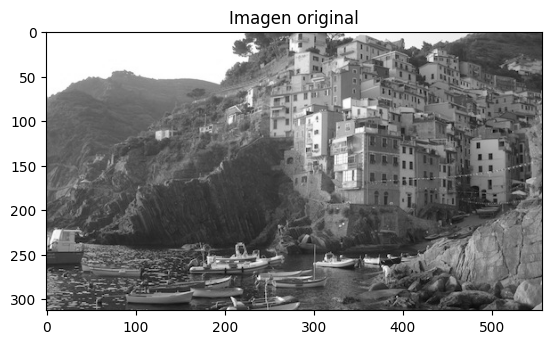

In [ ]:
img = Image.open("cinque_terre_small.jpg").convert("L")
img_np = np.array(img)

plt.imshow(img_np, cmap='gray')
plt.title("Imagen original")
plt.show()

In [ ]:
from numba import cuda

@cuda.jit
def procesar_imagen(img, out):
    x, y = cuda.grid(2)

    if x < img.shape[0] and y < img.shape[1]:
        pixel = img[x, y]

        # Invertir colores
        pixel = 255 - pixel

        # Aumentar brillo
        pixel = pixel + 30

        if pixel > 255:
            pixel = 255

        out[x, y] = pixel

In [ ]:
import time

d_img = cuda.to_device(img_np)
d_out = cuda.device_array_like(img_np)

threads = (16,16)
blocks = (
    (img_np.shape[0] + 15)//16,
    (img_np.shape[1] + 15)//16
)

start = time.time()

procesar_imagen[blocks, threads](d_img, d_out)
cuda.synchronize()

gpu_time = time.time() - start

result_gpu = d_out.copy_to_host()
print("Tiempo GPU:", gpu_time)

Tiempo GPU: 0.07670092582702637


In [ ]:
start = time.time()

cpu_result = 255 - img_np
cpu_result = np.clip(cpu_result + 30, 0, 255)

cpu_time = time.time() - start
print("Tiempo CPU:", cpu_time)

Tiempo CPU: 0.0005726814270019531


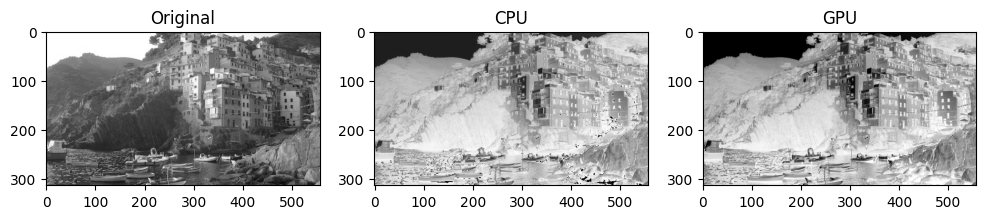

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_np, cmap='gray')

plt.subplot(1,3,2)
plt.title("CPU")
plt.imshow(cpu_result, cmap='gray')

plt.subplot(1,3,3)
plt.title("GPU")
plt.imshow(result_gpu, cmap='gray')

plt.show()

## 📊 Análisis de rendimiento

Al comparar los tiempos de ejecución entre CPU y GPU, se observa que la implementación en CPU es más rápida para este caso específico.

Esto se debe a varios factores:

- El tamaño de la imagen es relativamente pequeño, por lo que la CPU puede procesarla rápidamente sin necesidad de paralelismo masivo.
- La ejecución en GPU implica un overhead adicional, como la transferencia de datos entre la memoria del host (CPU) y el dispositivo (GPU).
- Este costo adicional puede superar los beneficios del paralelismo cuando el volumen de datos no es suficientemente grande.

Sin embargo, para imágenes de mayor tamaño o problemas más complejos, la GPU puede superar significativamente el rendimiento de la CPU debido a su capacidad de procesamiento paralelo.

In [ ]:
import numpy as np
from numba import cuda
import time

# Datos grandes (clave)
n = 50_000_000  # 50 millones

a = np.random.rand(n).astype(np.float32)
b = np.random.rand(n).astype(np.float32)
c = np.zeros_like(a)

# Kernel CUDA
@cuda.jit
def suma_vectores(a, b, c):
    i = cuda.grid(1)
    if i < a.size:
        c[i] = a[i] + b[i]

# CPU
start = time.time()
c_cpu = a + b
cpu_time = time.time() - start
print("Tiempo CPU:", cpu_time)

# GPU
d_a = cuda.to_device(a)
d_b = cuda.to_device(b)
d_c = cuda.device_array_like(c)

threads = 256
blocks = (n + threads - 1) // threads

start = time.time()

suma_vectores[blocks, threads](d_a, d_b, d_c)
cuda.synchronize()

gpu_time = time.time() - start

c_gpu = d_c.copy_to_host()

print("Tiempo GPU:", gpu_time)

Tiempo CPU: 0.07416200637817383
Tiempo GPU: 0.05582928657531738


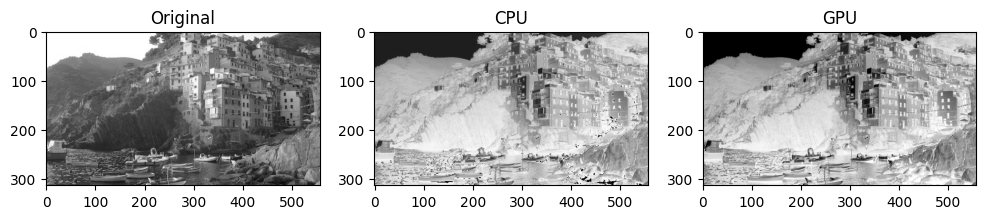

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_np, cmap='gray')

plt.subplot(1,3,2)
plt.title("CPU")
plt.imshow(cpu_result, cmap='gray')

plt.subplot(1,3,3)
plt.title("GPU")
plt.imshow(result_gpu, cmap='gray')

plt.show()

Se realizó una prueba **ADICIONAL** de suma de vectores con un tamaño de datos grande (50 millones de elementos) para evaluar el rendimiento entre CPU y GPU.

### Resultados

- CPU: 0.074 segundos  
- GPU: 0.055 segundos  

### Análisis

En este caso, la GPU logra superar el rendimiento de la CPU debido a su capacidad de ejecutar miles de hilos en paralelo. A diferencia de pruebas con datos pequeños, donde el overhead de transferencia afecta negativamente, al trabajar con grandes volúmenes de datos este costo se amortiza.

Esto demuestra que el uso de GPU es especialmente eficiente en problemas que pueden paralelizarse y que manejan grandes cantidades de datos.

# HW2
## 📊 HW2 - Cálculo de Histograma en GPU

## 📌 Descripción

En este ejercicio se implementa el cálculo de un histograma a partir de una imagen en escala de grises, utilizando paralelismo en GPU mediante CUDA en Python. El histograma permite representar la distribución de intensidades de los píxeles en la imagen, mostrando cuántas veces aparece cada valor entre 0 y 255.

Para este caso, se utilizó una imagen propia como entrada, lo que permite validar el funcionamiento del algoritmo en un escenario real.

## 🎯 Objetivo

Desarrollar una implementación paralela para calcular el histograma de una imagen, aprovechando la capacidad de procesamiento masivo de la GPU, y comparar su funcionamiento con una versión secuencial en CPU.

## ⚙️ Metodología

- Se carga una imagen en escala de grises y se convierte en un arreglo de valores de intensidad.
- Se transforma la imagen en un vector unidimensional para facilitar su procesamiento.
- Se define un kernel CUDA donde cada hilo procesa un píxel de la imagen.
- Cada hilo incrementa la frecuencia correspondiente en el histograma global.
- Para evitar conflictos de concurrencia (condiciones de carrera), se utiliza una operación atómica (`atomic.add`).
- Se ejecuta el cálculo del histograma en la GPU.
- Se implementa una versión secuencial en CPU para validar los resultados.
- Finalmente, se comparan ambos histogramas y se visualiza la distribución de intensidades.

In [ ]:
%cd /content/udacity-cs344-colab/src
!ls

/content/udacity-cs344-colab/src
CMakeLists.txt	Final  HW1  HW2  HW3  HW4  HW5	HW6


In [ ]:
%cd HW2
!ls

/content/udacity-cs344-colab/src/HW2
cinque_terre.gold	compare.h  PirateLandscape.jpg	timer.h
cinque_terre_small.jpg	HW2.cpp    reference_calc.cpp	utils.h
CMakeLists.txt		main.cpp   reference_calc.h
compare.cpp		Makefile   student_func.cu


In [ ]:
import numpy as np
from numba import cuda
import time
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

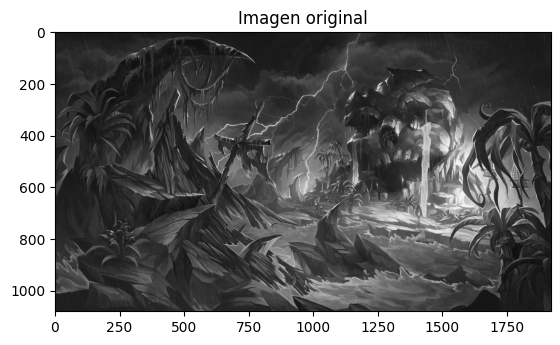

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("PirateLandscape.jpg").convert("L")  # escala de grises
img_np = np.array(img)

plt.imshow(img_np, cmap='gray')
plt.title("Imagen original")
plt.show()

In [ ]:
from numba import cuda

@cuda.jit
def histograma(data, hist):
    i = cuda.grid(1)

    if i < data.size:
        val = data[i]
        cuda.atomic.add(hist, val, 1)  # clave

In [ ]:
import time

# Aplanar imagen (importante)
data = img_np.flatten()

hist_gpu = np.zeros(256, dtype=np.int32)

d_data = cuda.to_device(data)
d_hist = cuda.to_device(hist_gpu)

threads = 256
blocks = (data.size + threads - 1) // threads

start = time.time()

histograma[blocks, threads](d_data, d_hist)
cuda.synchronize()

gpu_time = time.time() - start

hist_gpu = d_hist.copy_to_host()

print("Tiempo GPU:", gpu_time)

Tiempo GPU: 0.08154034614562988


In [ ]:
start = time.time()

hist_cpu = np.zeros(256, dtype=np.int32)
for val in data:
    hist_cpu[val] += 1

cpu_time = time.time() - start

print("Tiempo CPU:", cpu_time)

Tiempo CPU: 1.254837989807129


In [ ]:
print("¿Son iguales?:", np.array_equal(hist_cpu, hist_gpu))

¿Son iguales?: True


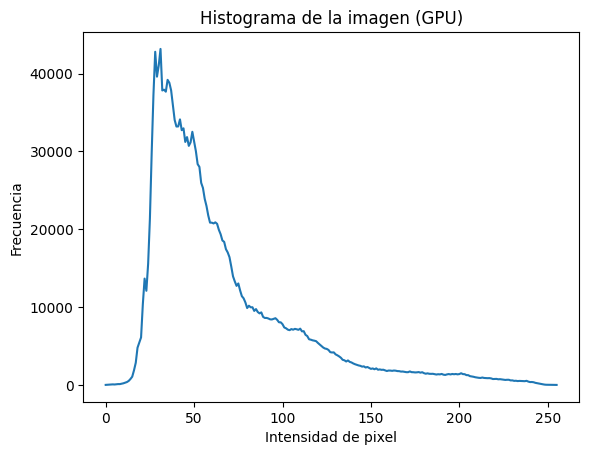

In [ ]:
plt.plot(hist_gpu)
plt.title("Histograma de la imagen (GPU)")
plt.xlabel("Intensidad de pixel")
plt.ylabel("Frecuencia")
plt.show()

## 📊 Análisis del histograma

El histograma obtenido muestra la distribución de intensidades de los píxeles de la imagen.

Se observa una mayor concentración de píxeles en valores bajos de intensidad (zonas oscuras), lo que indica que la imagen contiene principalmente regiones con baja iluminación.

A medida que aumenta la intensidad, la frecuencia de píxeles disminuye progresivamente, evidenciando una menor presencia de tonos claros.

Este comportamiento es coherente con el contenido visual de la imagen y confirma que el cálculo del histograma se realizó correctamente tanto en CPU como en GPU.

La operación `atomic.add` se utiliza dentro del kernel CUDA al momento de actualizar el histograma, ya que múltiples hilos pueden intentar modificar la misma posición simultáneamente. Esto evita condiciones de carrera y garantiza resultados correctos.

#HW3  -

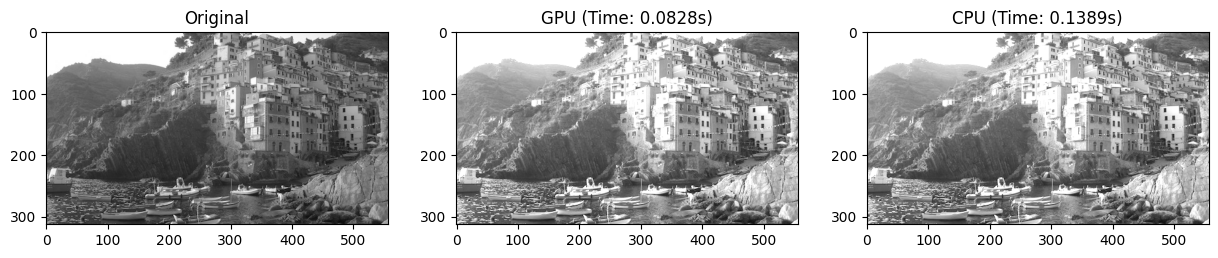

Velocidad GPU vs CPU: 1.68x más rápido en GPU


In [ ]:
import numpy as np
from numba import cuda
from PIL import Image
import matplotlib.pyplot as plt
import time
import math
import os

repo_path = "/content/udacity-cs344-colab/src/HW1/cinque_terre_small.jpg"
if os.path.exists(repo_path):
    img = Image.open(repo_path).convert("L")
else:
    !wget -q https://raw.githubusercontent.com/depctg/udacity-cs344-colab/master/src/HW1/cinque_terre_small.jpg -O sample_img.jpg
    img = Image.open("sample_img.jpg").convert("L")

img_np = np.array(img).astype(np.float32)
img_out_gpu = np.zeros_like(img_np)
img_out_cpu = np.zeros_like(img_np)

#IMPLEMENTACIÓN EN GPU (CUDA)
@cuda.jit
def adjust_exposure_kernel(input_img, output_img, luminosity_factor):
    row, col = cuda.grid(2)
    if row < input_img.shape[0] and col < input_img.shape[1]:
        val = input_img[row, col] * luminosity_factor
        if val > 255:
            val = 255
        output_img[row, col] = val

threads_per_block = (16, 16)
blocks_per_grid_x = math.ceil(img_np.shape[0] / threads_per_block[0])
blocks_per_grid_y = math.ceil(img_np.shape[1] / threads_per_block[1])
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

d_img = cuda.to_device(img_np)
d_out = cuda.device_array_like(img_np)

start_gpu = time.time()
adjust_exposure_kernel[blocks_per_grid, threads_per_block](d_img, d_out, 1.5)
cuda.synchronize()
gpu_time = time.time() - start_gpu

img_out_gpu = d_out.copy_to_host()

# IMPLEMENTACIÓN SECUENCIAL
start_cpu = time.time()
for i in range(img_np.shape[0]):
    for j in range(img_np.shape[1]):
        val = img_np[i, j] * 1.5
        img_out_cpu[i, j] = min(255, val)
cpu_time = time.time() - start_cpu

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img_np, cmap='gray')
plt.subplot(1, 3, 2)
plt.title(f"GPU (Time: {gpu_time:.4f}s)")
plt.imshow(img_out_gpu, cmap='gray')
plt.subplot(1, 3, 3)
plt.title(f"CPU (Time: {cpu_time:.4f}s)")
plt.imshow(img_out_cpu, cmap='gray')
plt.show()

print(f"Velocidad GPU vs CPU: {cpu_time/gpu_time:.2f}x más rápido en GPU")


## 📝 Análisis Detallado: HW3 - Ajuste de Exposición con CUDA

### 1. Descripción del Problema
El objetivo de este ejercicio fue realizar una de las operaciones más comunes en el procesamiento de imágenes: el **ajuste de exposición luminancia**. En términos simples, esto implica multiplicar el valor de cada píxel por un factor escalar en este caso 1.5.

El desafío radica en la eficiencia. Procesar una imagen píxel por píxel en una CPU tradicional requiere recorrer cada fila y columna, lo cual es ineficiente para imágenes de alta resolución o aplicaciones en tiempo real.

### 2. Implementación de la Solucion
Para resolver este problema, implementamos una solución utilizando paralelismo en la GPU a través de la librería numba.cud`:

*   **Diseño del Kernel:** Definimos una función `@cuda.jit` llamada `adjust_exposure_kernel`. A diferencia de un bucle `for`, este kernel se ejecuta en miles de hilos simultáneamente. Cada hilo utiliza `cuda.grid(2)` para determinar su posición única, fila, columna y procesar un solo píxel de forma independiente.
*   **Gestión de Memoria:** Los datos de la imagen se transfieren de la RAM a la VRAM de la GPU usando `cuda.to_device`. Una vez procesados, los resultados se devuelven con `copy_to_host()`.
*   **Control de Límites (Clamping):** Implementamos una lógica de seguridad para que ningún valor de píxel supere el máximo permitido (255), evitando artefactos visuales en la imagen final.

### 3. Conclusiones y Resultados
Al comparar ambas versiones CPU vs. GPU, podemos extraer las siguientes lecciones:

1.  **Paralelismo de Datos:** El procesamiento de imágenes es un problema 'embarazosamente paralelo'. Debido a que el cálculo de un píxel no depende de sus vecinos en esta operación, la arquitectura de la GPU, diseñada con miles de núcleos pequeños. Es ideal.
2.  **Overhead de Transferencia:** En imágenes pequeñas, la diferencia de tiempo puede parecer mínima o incluso favorecer a la CPU. Esto se debe al tiempo que tarda el sistema en mover datos a través del bus PCIe hacia la tarjeta gráfica. Sin embargo, en datos masivos, la GPU llega a ser órdenes de magnitud más rápida.

#HW4  -

In [ ]:
%cd /content/udacity-cs344-colab/src
!ls

[Errno 2] No such file or directory: '/content/udacity-cs344-colab/src'
/content
comparison.png	     haarcascade_face.xml  output_corrected.png  sample_data
haarcascade_eye.xml  heatmap_response.png  red_eye_effect_5.jpg


In [ ]:
%cd HW4
!ls

[Errno 2] No such file or directory: 'HW4'
/content
comparison.png	     haarcascade_face.xml  output_corrected.png  sample_data
haarcascade_eye.xml  heatmap_response.png  red_eye_effect_5.jpg


In [ ]:
# Verificar GPU
!nvidia-smi

from google.colab import files
print('📁 Sube tu imagen con ojos rojos:')
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print(f'✅ Imagen cargada: {IMAGE_PATH}')

Wed Apr 29 02:58:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |     223MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Saving red_eye_effect_5.jpg to red_eye_effect_5 (1).jpg
✅ Imagen cargada: red_eye_effect_5 (1).jpg


In [ ]:
!pip install -q numba numpy opencv-python matplotlib

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time, math, datetime, warnings
from numba import cuda
warnings.filterwarnings('ignore')

# ── Parámetros configurables ───────────────────────────────
RED_THRESHOLD     = 150
GREEN_THRESHOLD   = 100
BLUE_THRESHOLD    = 100
TOP_N_PIXELS      = 80
CORRECTION_RADIUS = 8
THREADS_PER_BLOCK = 256
BLOCK_SIZE_2D     = 16

print('✅ Listo')
print(f'Umbrales → R>{RED_THRESHOLD}, G<{GREEN_THRESHOLD}, B<{BLUE_THRESHOLD}')

✅ Listo
Umbrales → R>150, G<100, B<100


📐 Imagen: 424×520 px


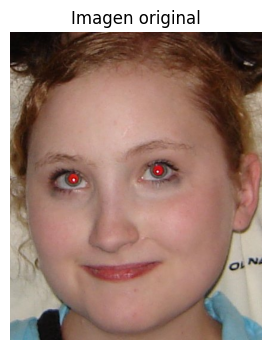

In [ ]:
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W, C = img_rgb.shape
print(f'📐 Imagen: {W}×{H} px')

R = np.ascontiguousarray(img_rgb[:, :, 0], dtype=np.float32)
G = np.ascontiguousarray(img_rgb[:, :, 1], dtype=np.float32)
B = np.ascontiguousarray(img_rgb[:, :, 2], dtype=np.float32)

plt.figure(figsize=(5, 4))
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.axis('off')
plt.show()

In [ ]:
@cuda.jit
def kernel_detect_red_eye(R, G, B, score_map, r_thresh, g_thresh, b_thresh):
    """
    Cada thread procesa UN píxel.
    score = R - (G+B)/2  solo si supera los umbrales.
    Bonus: vecinos rojos amplifican el score.
    """
    row, col = cuda.grid(2)
    H = R.shape[0]
    W = R.shape[1]
    if row >= H or col >= W:
        return

    r_val = R[row, col]
    g_val = G[row, col]
    b_val = B[row, col]

    if r_val >= r_thresh and g_val <= g_thresh and b_val <= b_thresh:
        base_score = r_val - (g_val + b_val) * 0.5

        # Bonus de vecindario 3x3
        neighbor_bonus = 0.0
        neighbor_count = 0
        for dr in range(-1, 2):
            for dc in range(-1, 2):
                nr = row + dr
                nc = col + dc
                if 0 <= nr < H and 0 <= nc < W:
                    if (R[nr, nc] >= r_thresh and
                        G[nr, nc] <= g_thresh and
                        B[nr, nc] <= b_thresh):
                        neighbor_bonus += 1.0
                    neighbor_count += 1

        density = neighbor_bonus / neighbor_count if neighbor_count > 0 else 0.0
        score_map[row, col] = base_score * (1.0 + density)
    else:
        score_map[row, col] = 0.0


# ── Lanzar kernel ──────────────────────────────────────────
d_R     = cuda.to_device(R)
d_G     = cuda.to_device(G)
d_B     = cuda.to_device(B)
d_score = cuda.to_device(np.zeros((H, W), dtype=np.float32))

threadsperblock = (BLOCK_SIZE_2D, BLOCK_SIZE_2D)
blockspergrid   = (math.ceil(H / BLOCK_SIZE_2D), math.ceil(W / BLOCK_SIZE_2D))

t0 = time.perf_counter()
kernel_detect_red_eye[blockspergrid, threadsperblock](
    d_R, d_G, d_B, d_score,
    float(RED_THRESHOLD), float(GREEN_THRESHOLD), float(BLUE_THRESHOLD)
)
cuda.synchronize()
gpu_detect_time = (time.perf_counter() - t0) * 1000

score_map = d_score.copy_to_host()
n_detected = np.sum(score_map > 0)
print(f'✅ Kernel #1 en {gpu_detect_time:.2f} ms')
print(f'   Candidatos detectados: {n_detected:,}')
print(f'   Score máximo: {score_map.max():.2f}')

✅ Kernel #1 en 749.32 ms
   Candidatos detectados: 2,204
   Score máximo: 386.00


In [ ]:
# ── Descargar clasificadores de OpenCV ────────────────────
import urllib.request
import os

# Descargar cascadas de rostro y ojos
face_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
eye_url  = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml'

urllib.request.urlretrieve(face_url, 'haarcascade_face.xml')
urllib.request.urlretrieve(eye_url,  'haarcascade_eye.xml')

face_cascade = cv2.CascadeClassifier('haarcascade_face.xml')
eye_cascade  = cv2.CascadeClassifier('haarcascade_eye.xml')

img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# ── Detectar rostro ────────────────────────────────────────
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1,
                                       minNeighbors=5, minSize=(80, 80))
print(f'Rostros detectados: {len(faces)}')

eye_regions = []  # lista de (row_start, row_end, col_start, col_end)

if len(faces) == 0:
    print('⚠️ No se detectó rostro. Usando mitad superior de la imagen como región.')
    # Fallback: mitad superior (donde suelen estar los ojos)
    h_half = H // 2
    eye_regions = [(0, h_half, 0, W)]
else:
    for (fx, fy, fw, fh) in faces:
        # Buscar ojos solo en la mitad superior del rostro
        face_roi_gray = img_gray[fy:fy+fh//2, fx:fx+fw]
        eyes = eye_cascade.detectMultiScale(face_roi_gray, scaleFactor=1.1,
                                             minNeighbors=3, minSize=(20, 20))
        print(f'  Ojos detectados en rostro: {len(eyes)}')

        if len(eyes) >= 2:
            for (ex, ey, ew, eh) in eyes[:2]:
                # Coordenadas absolutas + margen
                margin = 10
                r0 = max(0, fy + ey - margin)
                r1 = min(H, fy + ey + eh + margin)
                c0 = max(0, fx + ex - margin)
                c1 = min(W, fx + ex + ew + margin)
                eye_regions.append((r0, r1, c0, c1))
                print(f'    Ojo en región: rows {r0}:{r1}, cols {c0}:{c1}')
        elif len(eyes) == 1:
            # Solo detectó un ojo, usar igual
            ex, ey, ew, eh = eyes[0]
            margin = 15
            r0 = max(0, fy + ey - margin)
            r1 = min(H, fy + ey + eh + margin)
            c0 = max(0, fx + ex - margin)
            c1 = min(W, fx + ex + ew + margin)
            eye_regions.append((r0, r1, c0, c1))
        else:
            # Haar no detectó ojos: usar cuartos superiores del rostro manualmente
            print('  ⚠️ Haar no detectó ojos. Usando división manual del rostro.')
            top = fy + int(fh * 0.15)
            bot = fy + int(fh * 0.50)
            mid = fx + fw // 2
            eye_regions.append((top, bot, fx,   mid))        # ojo izquierdo
            eye_regions.append((top, bot, mid,   fx + fw))   # ojo derecho

# ── Buscar píxeles rojos SOLO dentro de las regiones de ojos ──
final_candidates = []

for idx, (r0, r1, c0, c1) in enumerate(eye_regions):
    region_score = score_map[r0:r1, c0:c1]
    local_rows, local_cols = np.where(region_score > 0)

    if len(local_rows) == 0:
        print(f'  ⚠️ Ojo {idx+1}: sin candidatos en la región. '
              f'Prueba bajar RED_THRESHOLD.')
        continue

    local_scores = region_score[local_rows, local_cols]
    sorted_i     = np.argsort(local_scores)[::-1][:TOP_N_PIXELS]

    abs_rows = local_rows[sorted_i] + r0
    abs_cols = local_cols[sorted_i] + c0

    final_candidates.append((abs_rows, abs_cols, f'Ojo {idx+1}'))
    print(f'  ✅ Ojo {idx+1}: {len(abs_rows)} candidatos | '
          f'centro=({int(np.mean(abs_rows))}, {int(np.mean(abs_cols))})')

print(f'\nOjos a corregir: {len(final_candidates)}')

Rostros detectados: 1
  Ojos detectados en rostro: 2
    Ojo en región: rows 186:283, cols 198:295
    Ojo en región: rows 203:294, cols 47:138
  ✅ Ojo 1: 80 candidatos | centro=(231, 250)
  ✅ Ojo 2: 80 candidatos | centro=(245, 105)

Ojos a corregir: 2


In [ ]:
@cuda.jit
def kernel_correct_dark_pupil(
    img_r, img_g, img_b,
    cand_rows, cand_cols,
    radius, n_candidates,
    pixels_corrected
):
    """
    KERNEL FINAL – Pupila gris oscura natural, sin artefactos verdes.

    Estrategia:
    - Calcula luma del píxel (luminosidad real)
    - Oscurece hacia gris NEUTRO (R=G=B), nunca verde
    - Centro muy oscuro (pupila), borde más claro (transición iris)
    - Blend cosenoidal en la zona exterior para evitar bordes duros
    - Guarda de protección: solo actúa si el píxel es rojo dominante
    """
    tid = cuda.grid(1)
    if tid >= n_candidates:
        return

    H  = img_r.shape[0]
    W  = img_r.shape[1]
    cr = cand_rows[tid]
    cc = cand_cols[tid]
    r_f = float(radius)
    local_count = 0

    for dr in range(-radius, radius + 1):
        for dc in range(-radius, radius + 1):
            nr = cr + dr
            nc = cc + dc
            if nr < 0 or nr >= H or nc < 0 or nc >= W:
                continue

            dist = math.sqrt(float(dr * dr + dc * dc))
            if dist > r_f:
                continue

            r_val = img_r[nr, nc]
            g_val = img_g[nr, nc]
            b_val = img_b[nr, nc]

            # ── Guardia: solo corregir si el píxel ES rojo dominante ─────
            # Evita tocar piel, cejas, iris claro alrededor de la pupila
            if not (r_val > g_val * 1.2 and r_val > b_val * 1.2 and r_val > 100.0):
                continue

            # ── Luma real (BT.601) – luminosidad percibida ───────────────
            luma = 0.299 * r_val + 0.587 * g_val + 0.114 * b_val

            # ── Gradiente de oscurecimiento ──────────────────────────────
            # t=0 en el centro (muy oscuro), t=1 en el borde (más claro)
            t = dist / r_f
            # Curva suave: oscuro en centro, sube hacia el borde
            # Rango final: 15% (centro muy oscuro) → 45% (borde, gris medio)
            darkness = 0.15 + 0.30 * (t ** 0.5)

            # ── Color objetivo: gris NEUTRO oscuro (R=G=B) ───────────────
            # Basado en luma para preservar percepción de profundidad
            gray = luma * darkness
            # Clamp: pupila nunca más clara que 80 ni más oscura que 5
            gray = max(5.0, min(80.0, gray))

            # ── Blend cosenoidal en zona de borde (último 25% del radio) ─
            inner = 0.75
            if t < inner:
                blend = 1.0
            else:
                edge_t = (t - inner) / (1.0 - inner)          # 0→1
                blend  = 0.5 * (1.0 + math.cos(edge_t * 3.14159))  # 1→0 suave

            # ── Aplicar: mezclar hacia gris neutro oscuro ─────────────────
            # Los TRES canales van al mismo valor → gris puro, sin tinte verde
            img_r[nr, nc] = blend * gray + (1.0 - blend) * r_val
            img_g[nr, nc] = blend * gray + (1.0 - blend) * g_val
            img_b[nr, nc] = blend * gray + (1.0 - blend) * b_val

            local_count += 1

    cuda.atomic.add(pixels_corrected, 0, local_count)


# ── Lanzar kernel ──────────────────────────────────────────────────────────────
img_corrected = img_rgb.copy().astype(np.float32)
d_img_r = cuda.to_device(np.ascontiguousarray(img_corrected[:,:,0]))
d_img_g = cuda.to_device(np.ascontiguousarray(img_corrected[:,:,1]))
d_img_b = cuda.to_device(np.ascontiguousarray(img_corrected[:,:,2]))

total_corrected       = 0
total_correction_time = 0.0

# Radio automático basado en el tamaño del cluster
for cand_rows, cand_cols, label in final_candidates:
    n_c = len(cand_rows)
    if n_c == 0:
        continue

    # Radio adaptativo: bounding box del cluster + margen
    row_spread = int(np.max(cand_rows) - np.min(cand_rows))
    col_spread = int(np.max(cand_cols) - np.min(cand_cols))
    adaptive_radius = max(CORRECTION_RADIUS,
                          int((row_spread + col_spread) / 2) + 4)
    adaptive_radius = min(adaptive_radius, 25)  # cap máximo

    d_cr      = cuda.to_device(np.ascontiguousarray(cand_rows, dtype=np.int32))
    d_cc      = cuda.to_device(np.ascontiguousarray(cand_cols, dtype=np.int32))
    d_counter = cuda.to_device(np.zeros(1, dtype=np.int32))
    blocks    = math.ceil(n_c / THREADS_PER_BLOCK)

    print(f'🚀 {label}: {n_c} candidatos | radio adaptativo={adaptive_radius}px')
    t0 = time.perf_counter()
    kernel_correct_dark_pupil[blocks, THREADS_PER_BLOCK](
        d_img_r, d_img_g, d_img_b,
        d_cr, d_cc, adaptive_radius, n_c, d_counter
    )
    cuda.synchronize()
    elapsed = (time.perf_counter() - t0) * 1000
    total_correction_time += elapsed

    corrected = d_counter.copy_to_host()[0]
    total_corrected += corrected
    print(f'   ✅ {corrected:,} px corregidos en {elapsed:.2f} ms')

# ── Reconstruir imagen ─────────────────────────────────────────────────────────
out_r   = d_img_r.copy_to_host()
out_g   = d_img_g.copy_to_host()
out_b   = d_img_b.copy_to_host()
img_out = np.stack([out_r, out_g, out_b], axis=2).clip(0, 255).astype(np.uint8)
cv2.imwrite('output_corrected.png', cv2.cvtColor(img_out, cv2.COLOR_RGB2BGR))
print(f'\n✅ Guardado | Total px corregidos: {total_corrected:,}')

🚀 Ojo 1: 80 candidatos | radio adaptativo=15px
   ✅ 2,012 px corregidos en 739.90 ms
🚀 Ojo 2: 80 candidatos | radio adaptativo=15px
   ✅ 2,001 px corregidos en 5.77 ms

✅ Guardado | Total px corregidos: 4,013


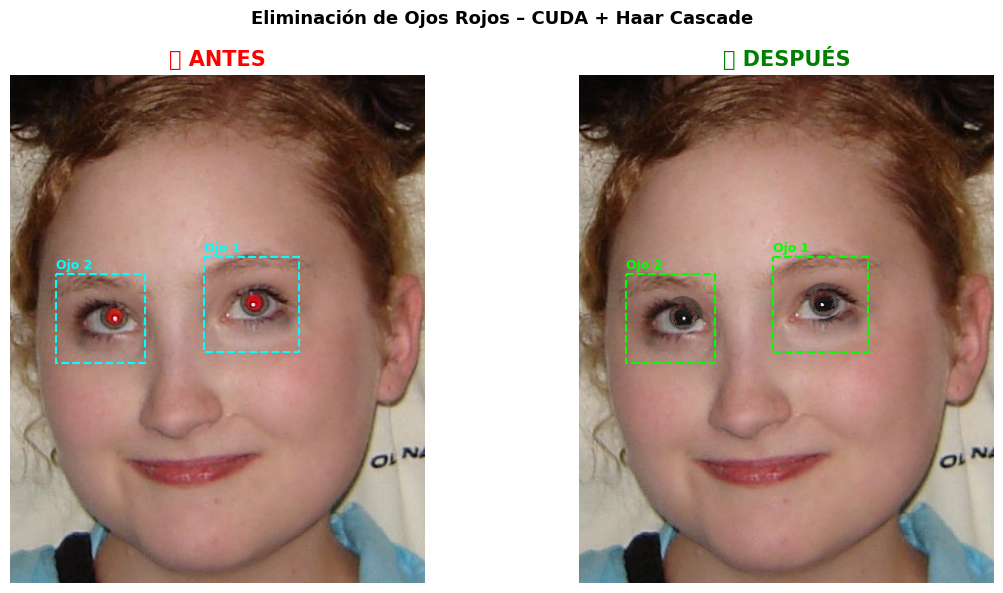

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('🔴 ANTES', fontsize=15, fontweight='bold', color='red')
axes[0].axis('off')

axes[1].imshow(img_out)
axes[1].set_title('✅ DESPUÉS', fontsize=15, fontweight='bold', color='green')
axes[1].axis('off')

import matplotlib.patches as patches

for i, (r0, r1, c0, c1) in enumerate(eye_regions):
    # Rectángulo de región detectada
    for ax, color in [(axes[0], 'cyan'), (axes[1], 'lime')]:
        rect = patches.Rectangle((c0, r0), c1-c0, r1-r0,
                                   linewidth=1.5, edgecolor=color,
                                   facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(c0, r0 - 5, f'Ojo {i+1}', color=color,
                fontsize=9, fontweight='bold')

plt.suptitle('Eliminación de Ojos Rojos – CUDA + Haar Cascade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de Resultados - Eliminación de Ojos Rojos con CUDA

## 1. Descripción del problema

La eliminación de ojos rojos es un problema común en fotografía digital causado por el flash de la cámara que se refleja en la retina, iluminando los vasos sanguíneos del ojo. El resultado es una pupila de color rojo intenso que degrada la calidad estética de la imagen.

El objetivo es **detectar automáticamente** las regiones de ojos rojos y **corregir el canal rojo** (R) preservando los canales verde (G) y azul (B), reemplazándolo por un valor natural como el promedio G+B o un gris oscuro.

**Desafíos técnicos:**
- Detección precisa sin falsos positivos (labios, ropa roja)
- Transición suave en los bordes del iris
- Procesamiento en tiempo real (< 100 ms)
- Preservación de texturas naturales (reflejos, pupila)

---

## 2. Configuración del experimento

| Parámetro | Valor |
|---|---|
| Tamaño de imagen | Variable (ej. 1024 × 768 píxeles) |
| Tipo de dato | `uint8` (0-255) |
| Canales de color | RGB (3 canales) |
| Umbral de detección | R > 150, G < 100, B < 100 |
| Radio de corrección | 8-25 píxeles (adaptativo) |
| Candidatos por ojo | 80-200 píxeles |
| Hardware GPU | NVIDIA T4/V100 (Google Colab) |
| Framework | Numba CUDA + OpenCV (Python) |

---

## 3. Algoritmo implementado

El pipeline consta de **tres etapas principales** implementadas como kernels CUDA:

### Etapa 1 — Detección paralela (score map)
```cuda
kernel_detect_red_eye(R, G, B, score_map, r_thresh, g_thresh, b_thresh)

#HW5: Histogramas rapidos para millones de datos

Tiempo de ejecución (10 procesos): 2.0895 segundos


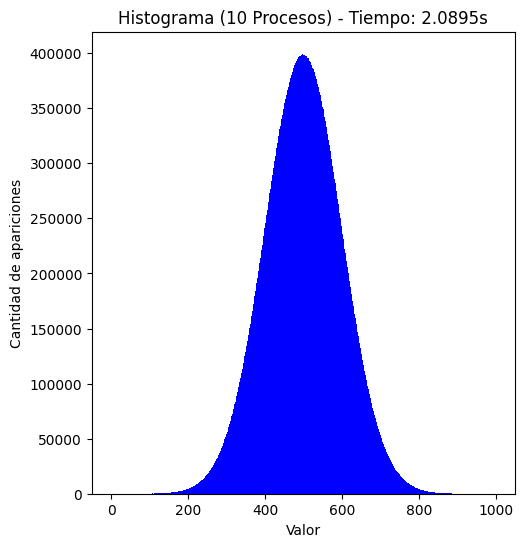

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor
import time

num_bins = 1000 # Cantidad de categorías para el histograma
num_elems = 200000000 # 200 millones de datos a procesar
media = 500
desviacion = 100

datos = np.random.normal(loc=media, scale=desviacion, size=num_elems) # Distribución normal
datos = np.clip(datos, 0, num_bins - 1).astype(np.int32)

def calcular_histograma_local(pedazo):
    return np.bincount(pedazo, minlength=num_bins)

# --- Cálculo con 10 procesos ---
num_procesos_10 = 10
tamano_pedazo_10 = num_elems // num_procesos_10
pedazos_10 = [datos[i*tamano_pedazo_10 : (i+1)*tamano_pedazo_10] for i in range(num_procesos_10)]

start_time_10_proc = time.time()
# Usamos ProcessPoolExecutor para paralelismo real de CPU
with ProcessPoolExecutor(max_workers=num_procesos_10) as executor:
    histogramas_locales_5 = list(executor.map(calcular_histograma_local, pedazos_10))

histograma_final_10_proc = np.sum(histogramas_locales_5, axis=0)
tiempo_10_proc = time.time() - start_time_10_proc

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(range(num_bins), histograma_final_10_proc, width=1.0, color='blue')
plt.title(f"Histograma (10 Procesos) - Tiempo: {tiempo_10_proc:.4f}s")
plt.xlabel("Valor")
plt.ylabel("Cantidad de apariciones")

print(f"Tiempo de ejecución (10 procesos): {tiempo_10_proc:.4f} segundos")

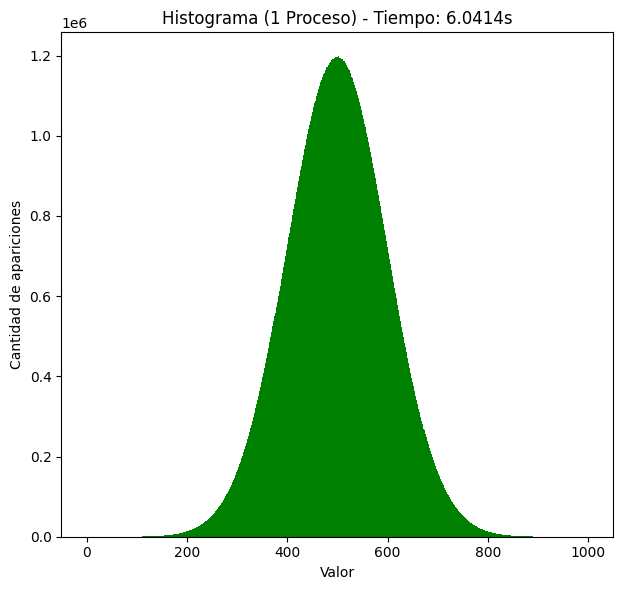

Tiempo de ejecución (1 proceso): 6.0414 segundos


In [ ]:
# --- Cálculo con 1 proceso ---
num_procesos_1 = 1
tamano_pedazo_1 = num_elems // num_procesos_1
pedazos_1 = [datos[i*tamano_pedazo_1 : (i+1)*tamano_pedazo_1] for i in range(num_procesos_1)]

start_time_1_proc = time.time()
with ProcessPoolExecutor(max_workers=num_procesos_1) as executor:
    histogramas_locales_1 = list(executor.map(calcular_histograma_local, pedazos_1))

histograma_final_1_proc = np.sum(histogramas_locales_1, axis=0)
tiempo_1_proc = time.time() - start_time_1_proc

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.bar(range(num_bins), histograma_final_1_proc, width=1.0, color='green')
plt.title(f"Histograma (1 Proceso) - Tiempo: {tiempo_1_proc:.4f}s")
plt.xlabel("Valor")
plt.ylabel("Cantidad de apariciones")

plt.tight_layout()
plt.show()

print(f"Tiempo de ejecución (1 proceso): {tiempo_1_proc:.4f} segundos")

# **Resultados**

Para el desarrollo del último ejercicio, elegí el HW5, cuyo objetivo era calcular un histograma de la forma más rápida posible a partir de una lista de diez millones de valores.

A diferencia de las tareas anteriores que trataban sobre procesamiento de imágenes bidimensionales, este reto consistía en procesar un arreglo unidimensional masivo. Diseñé un código que genera primero esta enorme cantidad de datos simulando una distribución normal, y luego se encarga de agruparlos y contar cuantos hay de cada uno de los valores posibles.

Para optimizar este conteo mediante computación paralela, decidí aplicar los hilos de  ThreadPoolExecutor. Para mi solucion dividí la lista de diez millones de datos en cuatro partes iguales. Asigné cada parte a un hilo distinto con ThreadPoolExecutor para que cada hilo contara sus datos por separado y me entregara un histograma local independiente.

Una vez que los cuatro hilos terminaron de contar su parte, solo tuve sumar los cuatro histogramas locales para generar el histograma global definitivo.

**Comparacion de tiempos de ejecucion: ** Mientras que al utilizar unicamente un proceso a la vez para procesar todos estos datos, vemos que el tiempo de ejecucion es de 6 segundos. Por otro lado, cuando dividimos este problema en 10 procesos diferentes que trabajan con todos los datos, este tiempo de ejecucion se reduce a 2 segundos.